# Diabetes Risk Prediction and Analysis Using Clinical and Lifestyle Factors
**Author:** Ritik Sunil Toksiya  
**Course:** UMBC DATA 606 – Capstone  
**Instructor:** Dr. Chaojie (Jay) Wang  


## Project Overview

Diabetes is one of the most prevalent chronic diseases in the United States, 
affecting approximately 34.2 million Americans with millions more unaware of 
their condition or risk. Early identification of high-risk individuals can 
encourage lifestyle changes, support early medical consultation, and help 
public health officials target prevention efforts more effectively.

This project builds a machine learning model to predict diabetes risk using 
clinical, demographic, and lifestyle factors collected from the CDC Behavioral 
Risk Factor Surveillance System (BRFSS) 2015 survey.

## Dataset
- **Source:** CDC BRFSS 2015 via Kaggle
- **Size:** 253,680 records, 22 features
- **Target Variable:** Diabetes_012 (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)

## Research Questions
1. Can clinical, lifestyle, and demographic survey indicators accurately predict diabetes risk?
2. Which factors are most predictive of diabetes?
3. How do different machine learning models compare in performance?
4. Can model interpretation techniques explain predictions in a meaningful way?

## 1. Exploratory Data Analysis (EDA) 

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Display all the columns of the dataframes
pd.pandas.set_option('display.max_columns',None)

In [152]:
import os
os.chdir('/Users/ritiktoksiya/Downloads/Capstone_606')

df = pd.read_csv('diabetes_health_indicators(1).csv')
print(df.shape)
df.head()

(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,No diabetes,Yes,Yes,Yes,40.0,Yes,No,No,No,No,Yes,No,Yes,No,Poor,18.0,15.0,Yes,Female,60-64,High school graduate / GED,"$15,000–$20,000"
1,No diabetes,No,No,No,25.0,Yes,No,No,Yes,No,No,No,No,Yes,Good,0.0,0.0,No,Female,50-54,College graduate,"< $10,000"
2,No diabetes,Yes,Yes,Yes,28.0,No,No,No,No,Yes,No,No,Yes,Yes,Poor,30.0,30.0,Yes,Female,60-64,High school graduate / GED,"≥ $75,000"
3,No diabetes,Yes,No,Yes,27.0,No,No,No,Yes,Yes,Yes,No,Yes,No,Very good,0.0,0.0,No,Female,70-74,Grades 9–11,"$35,000–$50,000"
4,No diabetes,Yes,Yes,Yes,24.0,No,No,No,Yes,Yes,Yes,No,Yes,No,Very good,3.0,0.0,No,Female,70-74,Some college / Technical school,"$20,000–$25,000"


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  object 
 1   HighBP                253680 non-null  object 
 2   HighChol              253680 non-null  object 
 3   CholCheck             253680 non-null  object 
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  object 
 6   Stroke                253680 non-null  object 
 7   HeartDiseaseorAttack  253680 non-null  object 
 8   PhysActivity          253680 non-null  object 
 9   Fruits                253680 non-null  object 
 10  Veggies               253680 non-null  object 
 11  HvyAlcoholConsump     253680 non-null  object 
 12  AnyHealthcare         253680 non-null  object 
 13  NoDocbcCost           253680 non-null  object 
 14  GenHlth               253680 non-null  object 
 15  

In [156]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

There are no null values in the dataset

### Class Distribution Analysis

The target variable `Diabetes_012` has three classes:

- **No Diabetes (0):** 84.24% — majority class, heavily dominant
- **Diabetes (2):** 13.93% — moderate representation
- **Prediabetes (1):** 1.83% — severely underrepresented

This reveals a significant class imbalance problem, especially for the Prediabetes class which is nearly 46x underrepresented compared to the No Diabetes class. If left unaddressed, the model will be biased towards predicting No Diabetes for most cases. We will handle this using **SMOTE (Synthetic Minority Oversampling Technique)** before model training.

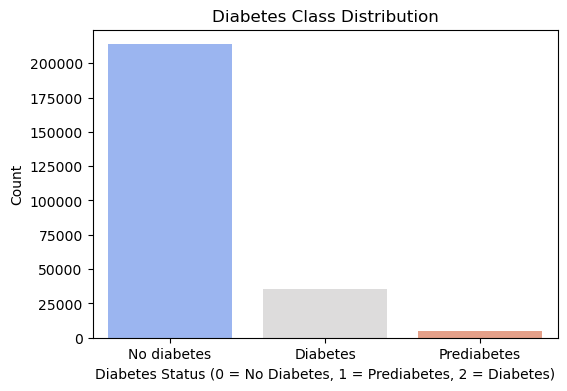

Class Distribution (%):
 Diabetes_012
No diabetes    84.241170
Diabetes       13.933302
Prediabetes     1.825528
Name: proportion, dtype: float64


In [158]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_012', data=df, hue='Diabetes_012', palette='coolwarm', legend=False)
plt.title('Diabetes Class Distribution')
plt.xlabel('Diabetes Status (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)')
plt.ylabel('Count')
plt.show()

# Print percentage distribution
class_dist = df['Diabetes_012'].value_counts(normalize=True) * 100
print("Class Distribution (%):\n", class_dist)

### 2. Categorical Features Analysis

In this section we analyze the categorical features in the dataset. 
Most features are binary (Yes/No) while some have multiple categories 
such as GenHlth (5 categories), Age (13 groups), Education (6 levels) 
and Income (8 brackets).

In [161]:
# Identifying Categorical Features
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("Number of Categorical Features:", len(categorical_features))
print("\nCategorical Features:", categorical_features)

df[categorical_features].head()

Number of Categorical Features: 19

Categorical Features: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,DiffWalk,Sex,Age,Education,Income
0,No diabetes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,No,Yes,No,Poor,Yes,Female,60-64,High school graduate / GED,"$15,000–$20,000"
1,No diabetes,No,No,No,Yes,No,No,Yes,No,No,No,No,Yes,Good,No,Female,50-54,College graduate,"< $10,000"
2,No diabetes,Yes,Yes,Yes,No,No,No,No,Yes,No,No,Yes,Yes,Poor,Yes,Female,60-64,High school graduate / GED,"≥ $75,000"
3,No diabetes,Yes,No,Yes,No,No,No,Yes,Yes,Yes,No,Yes,No,Very good,No,Female,70-74,Grades 9–11,"$35,000–$50,000"
4,No diabetes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,No,Yes,No,Very good,No,Female,70-74,Some college / Technical school,"$20,000–$25,000"


In [163]:
# Number of unique categories in each categorical feature
for feature in categorical_features:
    print("Feature: {} | Unique Categories: {} | Values: {}".format(
        feature, len(df[feature].unique()), df[feature].unique()))


Feature: Diabetes_012 | Unique Categories: 3 | Values: ['No diabetes' 'Diabetes' 'Prediabetes']
Feature: HighBP | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: HighChol | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: CholCheck | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: Smoker | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: Stroke | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: HeartDiseaseorAttack | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: PhysActivity | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: Fruits | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: Veggies | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: HvyAlcoholConsump | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: AnyHealthcare | Unique Categories: 2 | Values: ['Yes' 'No']
Feature: NoDocbcCost | Unique Categories: 2 | Values: ['No' 'Yes']
Feature: GenHlth | Unique Categories: 5 | Values: ['Poor' 'Good' 'Very good' 'Fair' 'Excellent']
Feature: DiffW

<Figure size 800x400 with 0 Axes>

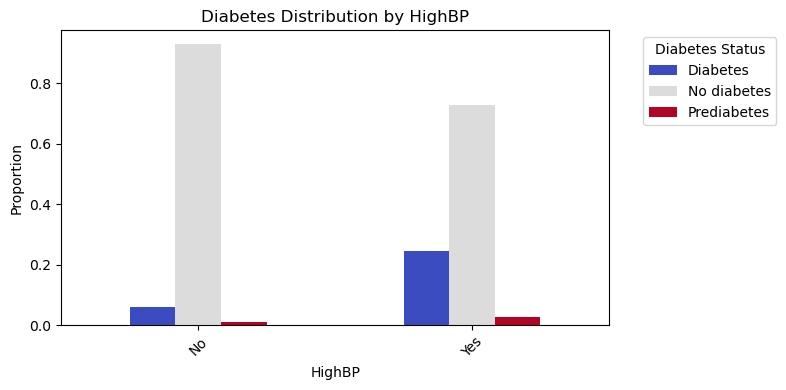

<Figure size 800x400 with 0 Axes>

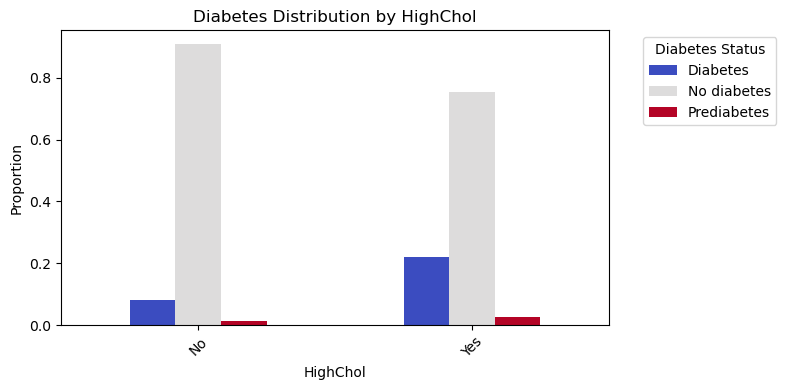

<Figure size 800x400 with 0 Axes>

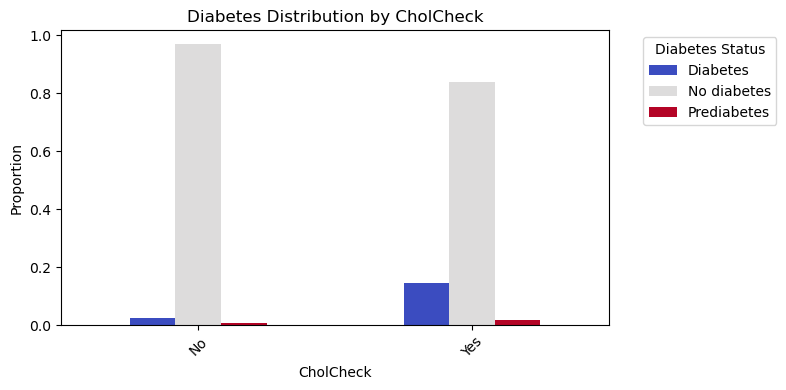

<Figure size 800x400 with 0 Axes>

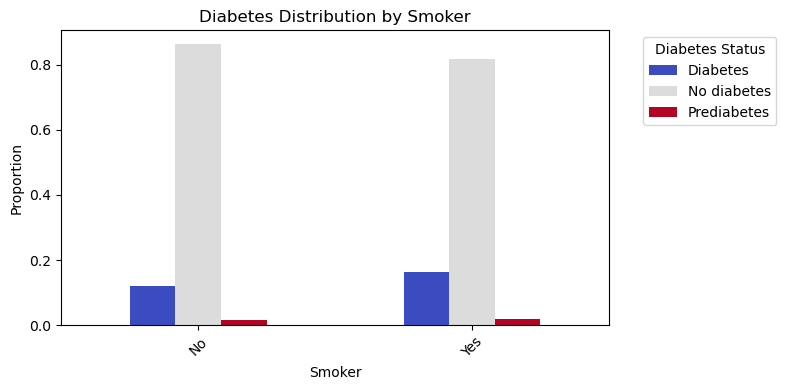

<Figure size 800x400 with 0 Axes>

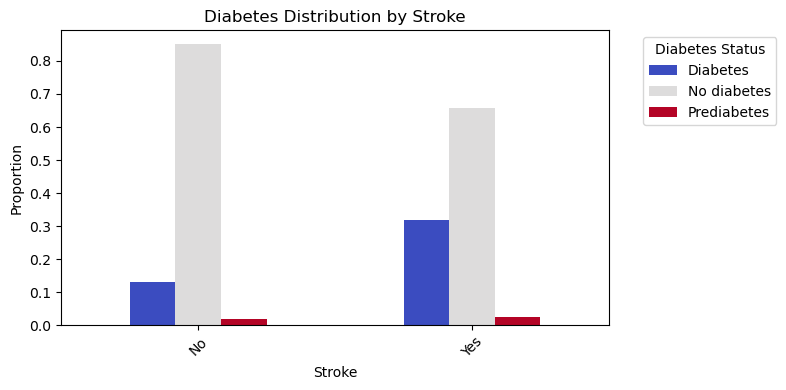

<Figure size 800x400 with 0 Axes>

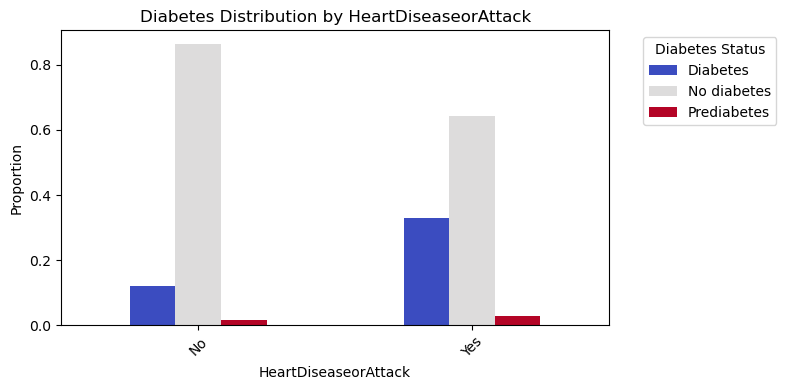

<Figure size 800x400 with 0 Axes>

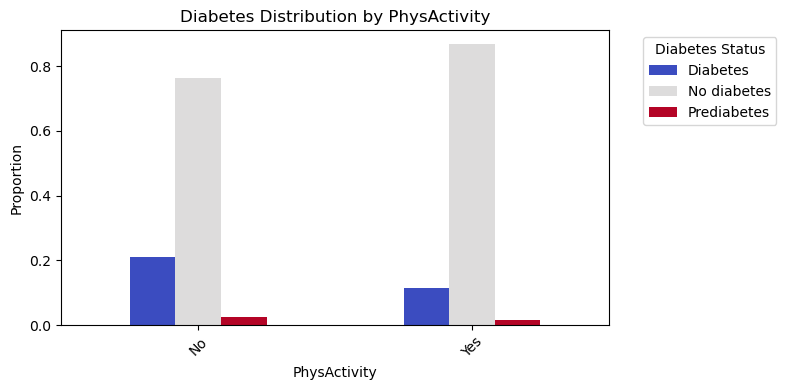

<Figure size 800x400 with 0 Axes>

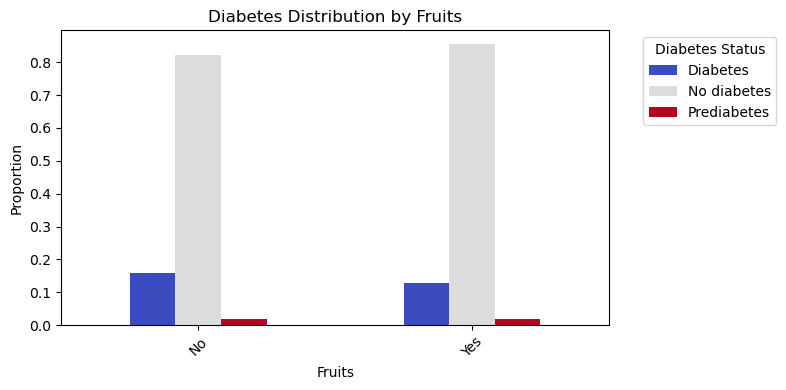

<Figure size 800x400 with 0 Axes>

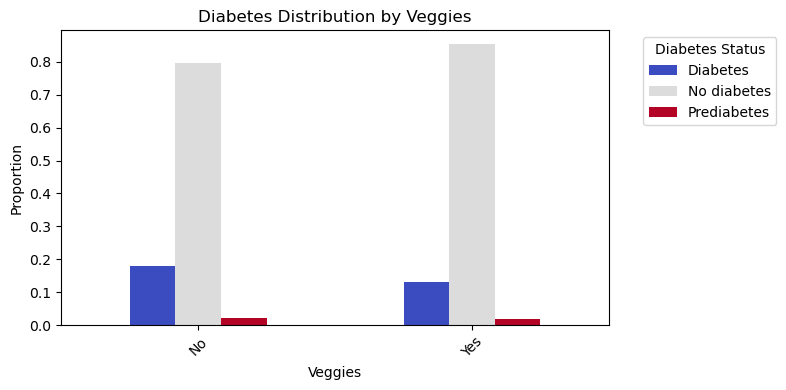

<Figure size 800x400 with 0 Axes>

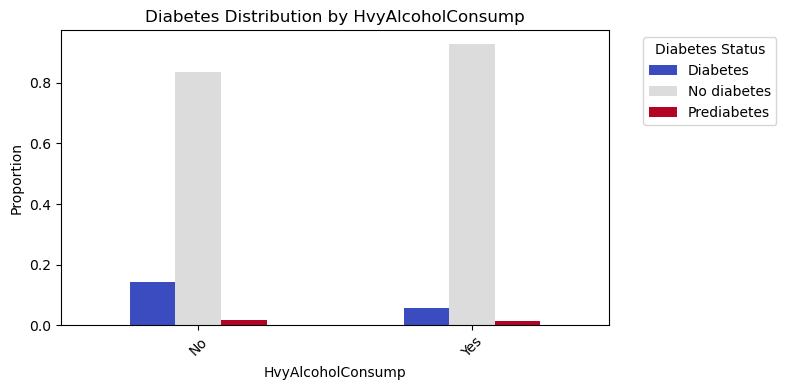

<Figure size 800x400 with 0 Axes>

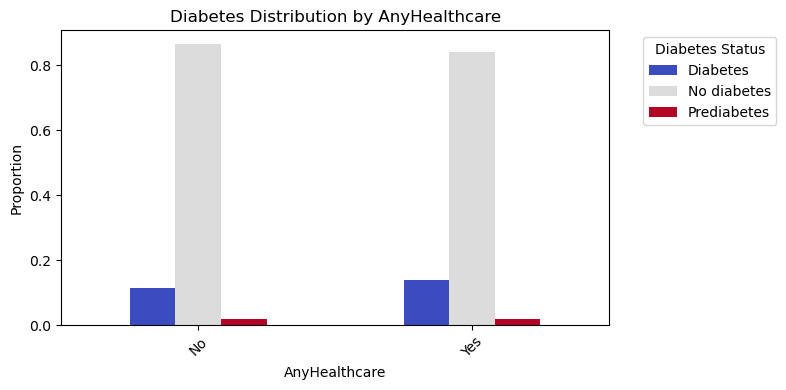

<Figure size 800x400 with 0 Axes>

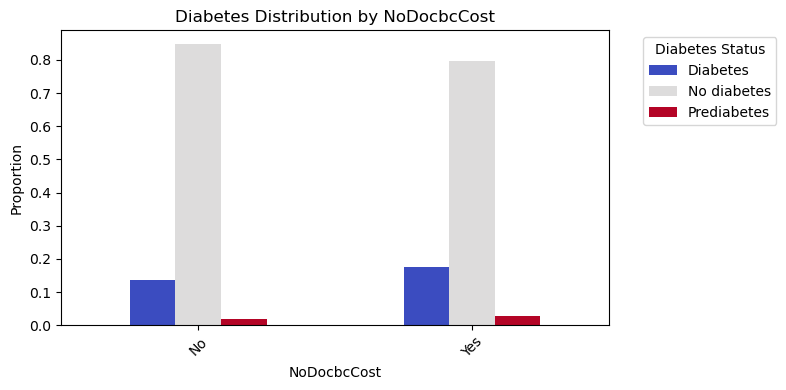

<Figure size 800x400 with 0 Axes>

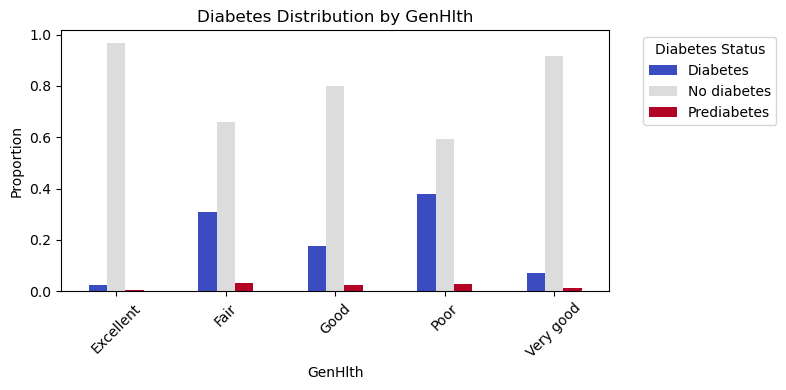

<Figure size 800x400 with 0 Axes>

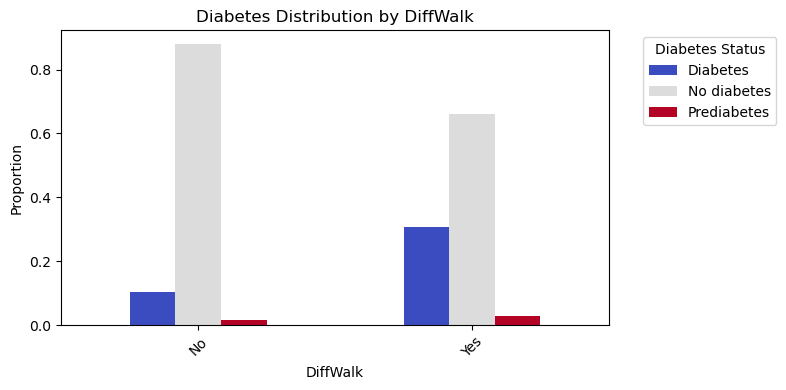

<Figure size 800x400 with 0 Axes>

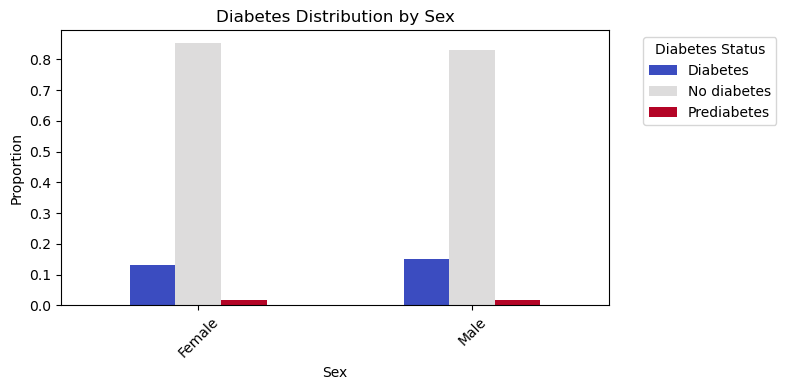

<Figure size 800x400 with 0 Axes>

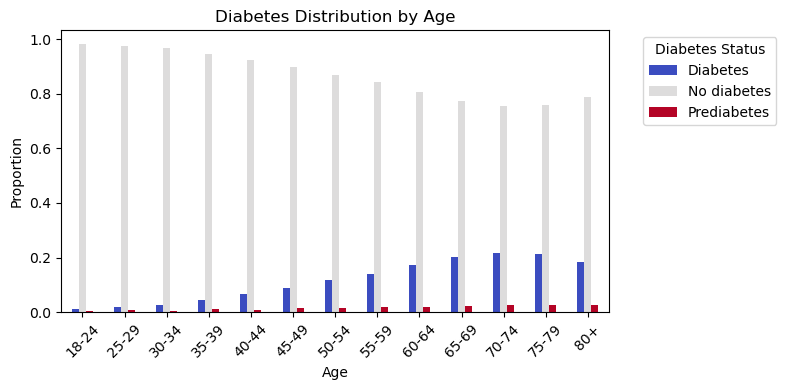

<Figure size 800x400 with 0 Axes>

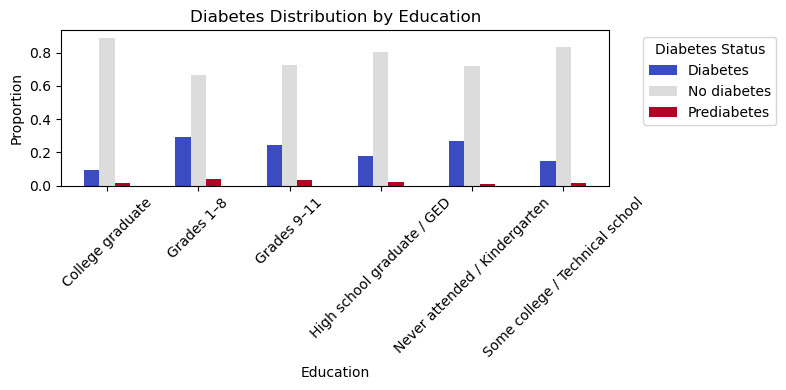

<Figure size 800x400 with 0 Axes>

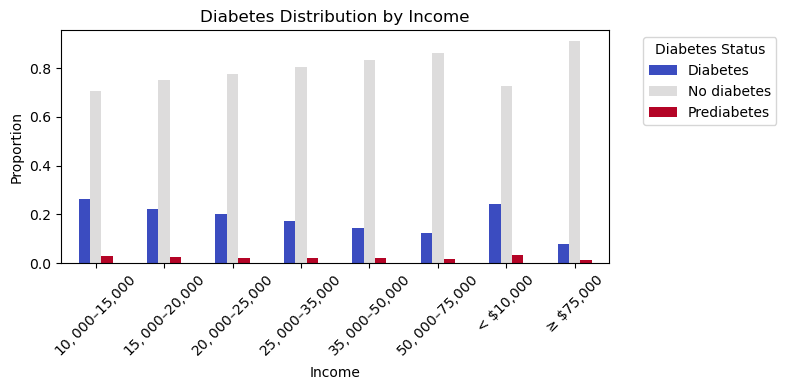

In [165]:
# Diabetes rate for each categorical feature (excluding target)
categorical_features_no_target = [f for f in categorical_features if f != 'Diabetes_012']

for feature in categorical_features_no_target:
    plt.figure(figsize=(8, 4))
    df.groupby(feature)['Diabetes_012'].value_counts(normalize=True).unstack().plot(
        kind='bar', colormap='coolwarm', figsize=(8, 4))
    plt.title(f'Diabetes Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Diabetes Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Categorical Features Analysis

1) **HighBP:** Respondents with high blood pressure have a significantly higher diabetes rate compared to those without.

2) **HighChol:** High cholesterol is associated with increased diabetes prevalence.

3) **CholCheck:** Respondents who had a cholesterol check show higher diabetes rates, likely because they are more health-conscious or already at risk.

4) **Smoker:** Smokers show a slightly higher diabetes rate compared to non-smokers.

5) **Stroke:** Respondents who had a stroke show a notably higher diabetes rate.

6) **HeartDiseaseorAttack:** History of heart disease or attack is strongly associated with higher diabetes rates.

7) **PhysActivity:** Physically active respondents show lower diabetes rates, suggesting physical activity is a protective factor.

8) **Fruits:** Daily fruit consumption shows a slight association with lower diabetes rates.

9) **Veggies:** Daily vegetable consumption is similarly associated with lower diabetes rates.

10) **HvyAlcoholConsump:** Heavy alcohol consumers show lower diabetes rates compared to non-heavy drinkers.

11) **AnyHealthcare:** Respondents with healthcare coverage show higher diabetes rates, possibly due to better diagnosis and reporting.

12) **NoDocbcCost:** Those who could not see a doctor due to cost show slightly higher diabetes rates.

13) **GenHlth:** Poor general health is the strongest categorical predictor — diabetes rates increase sharply as general health worsens from Excellent to Poor.

14) **DiffWalk:** Respondents with difficulty walking show significantly higher diabetes rates.

15) **Sex:** Males show slightly higher diabetes rates compared to females.

16) **Age:** Diabetes prevalence increases steadily with age, peaking in the 60-74 age groups and slightly declining after 75.

17) **Education:** Lower education levels are associated with higher diabetes rates, with college graduates showing the lowest rates.

18) **Income:** Higher income brackets show consistently lower diabetes rates, reflecting socioeconomic health disparities.

### 3. Numerical Features Analysis

The dataset contains 3 numerical features — BMI, MentHlth, and PhysHlth. 
We analyze their distributions and how they vary across the three diabetes classes.

In [170]:
# Identifying Numerical Features
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

print("Number of Numerical Features:", len(numerical_features))
print("\nNumerical Features:", numerical_features)

df[numerical_features].head()

Number of Numerical Features: 3

Numerical Features: ['BMI', 'MentHlth', 'PhysHlth']


,BMI,MentHlth,PhysHlth
0,40.0,18.0,15.0
1,25.0,0.0,0.0
2,28.0,30.0,30.0
3,27.0,0.0,0.0
4,24.0,3.0,0.0


### Numerical Features Distribution

1) **BMI:** Follows a right-skewed distribution with most respondents having a BMI between 20-35. 
A small number of respondents have extremely high BMI values (above 60), indicating the presence 
of outliers. Higher BMI is associated with increased diabetes risk.

2) **MentHlth:** Heavily zero-inflated — the majority of respondents reported 0 bad mental health 
days in the past 30 days. A smaller group reported the maximum of 30 bad days, suggesting a 
polarized distribution between people with no mental health issues and those with chronic issues.

3) **PhysHlth:** Similar to MentHlth, this is also heavily zero-inflated — most respondents 
reported 0 bad physical health days. The distribution shows that most people feel physically 
healthy most of the time, with a smaller group reporting persistent physical health problems.

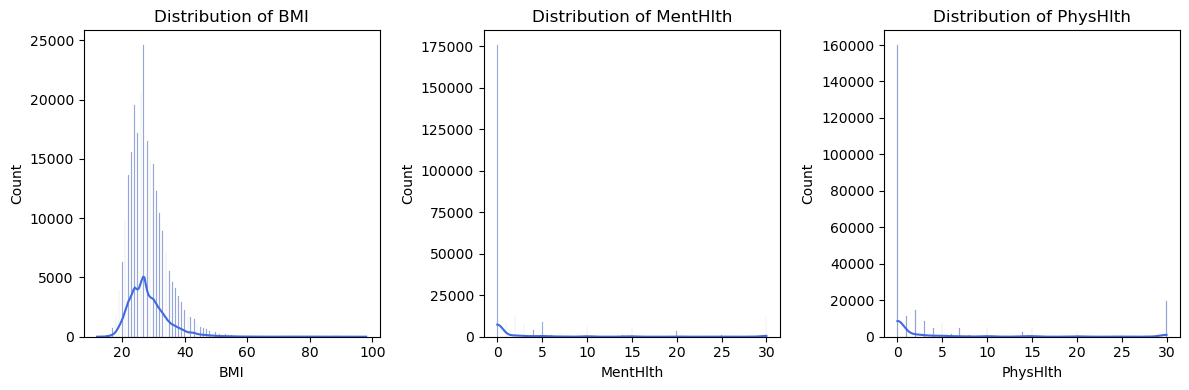

In [172]:
# Distribution of Numerical Features
plt.figure(figsize=(12, 4))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[feature], kde=True, color='royalblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

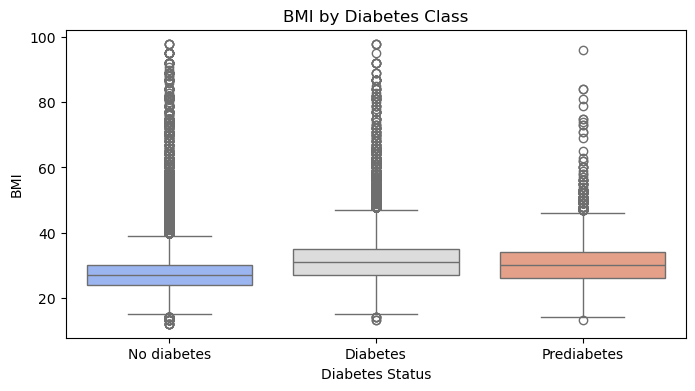

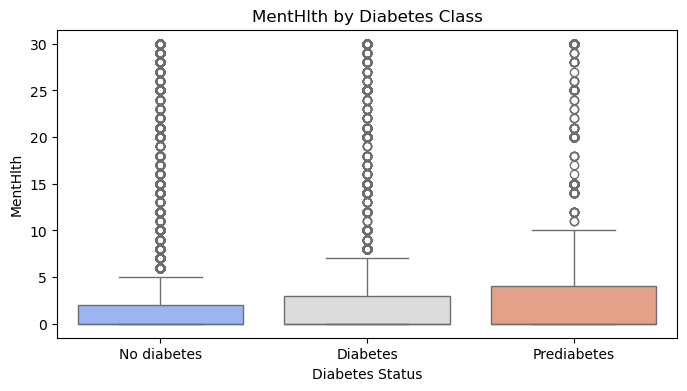

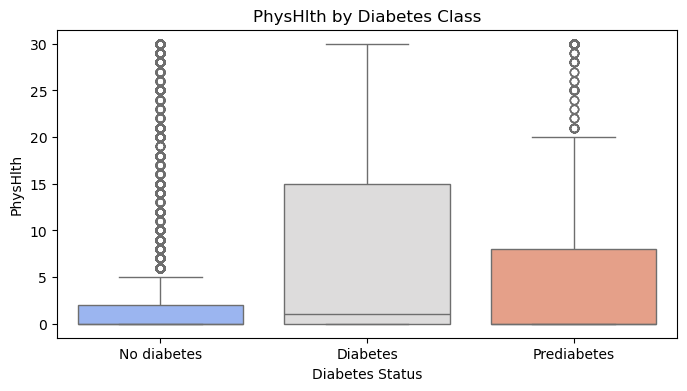

In [174]:
# Boxplots of Numerical Features by Diabetes Class
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df['Diabetes_012'], y=df[feature], hue=df['Diabetes_012'], palette='coolwarm')
    plt.title(f'{feature} by Diabetes Class')
    plt.xlabel('Diabetes Status')
    plt.ylabel(feature)
    plt.show()

### Boxplot Analysis of Numerical Features by Diabetes Class

1) **BMI:**
- No Diabetes group has the lowest median BMI (~27).
- Both Diabetes and Prediabetes groups have higher median BMI (~30-31).
- All three classes have outliers above BMI 60, indicating extreme cases exist across all groups.
- Higher BMI is clearly associated with increased diabetes risk.

2) **MentHlth:**
- All three classes have a median of 0, meaning most respondents reported no bad mental health days.
- However the Prediabetes group shows a slightly wider interquartile range, suggesting more mental health variability.
- The many outlier dots above represent people who reported multiple bad mental health days.
- Mental health alone is not a strong separator between classes.

3) **PhysHlth:**
- No Diabetes group has a median of 0 — most healthy respondents report no bad physical health days.
- Diabetes group shows a significantly higher median (~15 days), indicating diabetic respondents experience more physical health issues.
- Prediabetes group falls in between with a median around 7 days.
- PhysHlth is a stronger differentiator between classes compared to MentHlth.

## 4. Feature Encoding

Since the dataset contains text values (Yes/No, Male/Female, age groups etc.), 
we need to convert them to numeric values before model training.


In [178]:
# Binary columns - Yes/No encoding
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Sex encoding
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# Ordinal encoding - GenHlth
df['GenHlth'] = df['GenHlth'].map({'Excellent': 1, 'Very good': 2, 'Good': 3, 'Fair': 4, 'Poor': 5})

# Ordinal encoding - Age
age_mapping = {'18-24': 1, '25-29': 2, '30-34': 3, '35-39': 4, '40-44': 5,
               '45-49': 6, '50-54': 7, '55-59': 8, '60-64': 9, '65-69': 10,
               '70-74': 11, '75-79': 12, '80+': 13}
df['Age'] = df['Age'].map(age_mapping)

# Ordinal encoding - Education
education_mapping = {'Never attended / Kindergarten': 1, 'Grades 1-8': 2, 
                     'Grades 9-11': 3, 'High school graduate / GED': 4,
                     'Some college / Technical school': 5, 'College graduate': 6}
df['Education'] = df['Education'].map(education_mapping)

# Ordinal encoding - Income
income_mapping = {'< $10,000': 1, '$10,000-$15,000': 2, '$15,000-$20,000': 3,
                  '$20,000-$25,000': 4, '$25,000-$35,000': 5, '$35,000-$50,000': 6,
                  '$50,000-$75,000': 7, '≥ $75,000': 8}
df['Income'] = df['Income'].map(income_mapping)

# Target encoding
df['Diabetes_012'] = df['Diabetes_012'].map({'No diabetes': 0, 'Prediabetes': 1, 'Diabetes': 2})

print("Encoding done successfully")
print(df.dtypes)
df.head()

Encoding done successfully
Diabetes_012              int64
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
HeartDiseaseorAttack      int64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost               int64
GenHlth                   int64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Age                       int64
Education               float64
Income                  float64
dtype: object


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,1,0,1,0,5,18.0,15.0,1,0,9,4.0,NaN
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,1,3,0.0,0.0,0,0,7,6.0,1.0
2,0,1,1,1,28.0,0,0,0,0,1,0,0,1,1,5,30.0,30.0,1,0,9,4.0,8.0
3,0,1,0,1,27.0,0,0,0,1,1,1,0,1,0,2,0.0,0.0,0,0,11,NaN,NaN
4,0,1,1,1,24.0,0,0,0,1,1,1,0,1,0,2,3.0,0.0,0,0,11,5.0,NaN


In [180]:
print("Income unique values:", df['Income'].unique())
print("Education unique values:", df['Education'].unique())

Income unique values: [nan  1.  8.]
Education unique values: [ 4.  6. nan  5.  1.]


In [182]:
df_check = pd.read_csv('diabetes_health_indicators(1).csv')
print("Income unique values:", df_check['Income'].unique())
print("Education unique values:", df_check['Education'].unique())

Income unique values: ['$15,000–$20,000' '< $10,000' '≥ $75,000' '$35,000–$50,000'
 '$20,000–$25,000' '$50,000–$75,000' '$10,000–$15,000' '$25,000–$35,000']
Education unique values: ['High school graduate / GED' 'College graduate' 'Grades 9–11'
 'Some college / Technical school' 'Grades 1–8'
 'Never attended / Kindergarten']


In [184]:
# Fix Income mapping
income_mapping = {'< $10,000': 1, '$10,000–$15,000': 2, '$15,000–$20,000': 3,
                  '$20,000–$25,000': 4, '$25,000–$35,000': 5, '$35,000–$50,000': 6,
                  '$50,000–$75,000': 7, '≥ $75,000': 8}
df['Income'] = df_check['Income'].map(income_mapping)

# Fix Education mapping
education_mapping = {'Never attended / Kindergarten': 1, 'Grades 1–8': 2,
                     'Grades 9–11': 3, 'High school graduate / GED': 4,
                     'Some college / Technical school': 5, 'College graduate': 6}
df['Education'] = df_check['Education'].map(education_mapping)

print("Null values in Income:", df['Income'].isnull().sum())
print("Null values in Education:", df['Education'].isnull().sum())
df[['Income', 'Education']].head()

Null values in Income: 0
Null values in Education: 0


,Income,Education
0,3,4
1,1,6
2,8,4
3,6,3
4,4,5


In [186]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## 5. Correlation Heatmap

After encoding all features to numeric values, we can now analyze the 
correlations between all features and the target variable Diabetes_012.

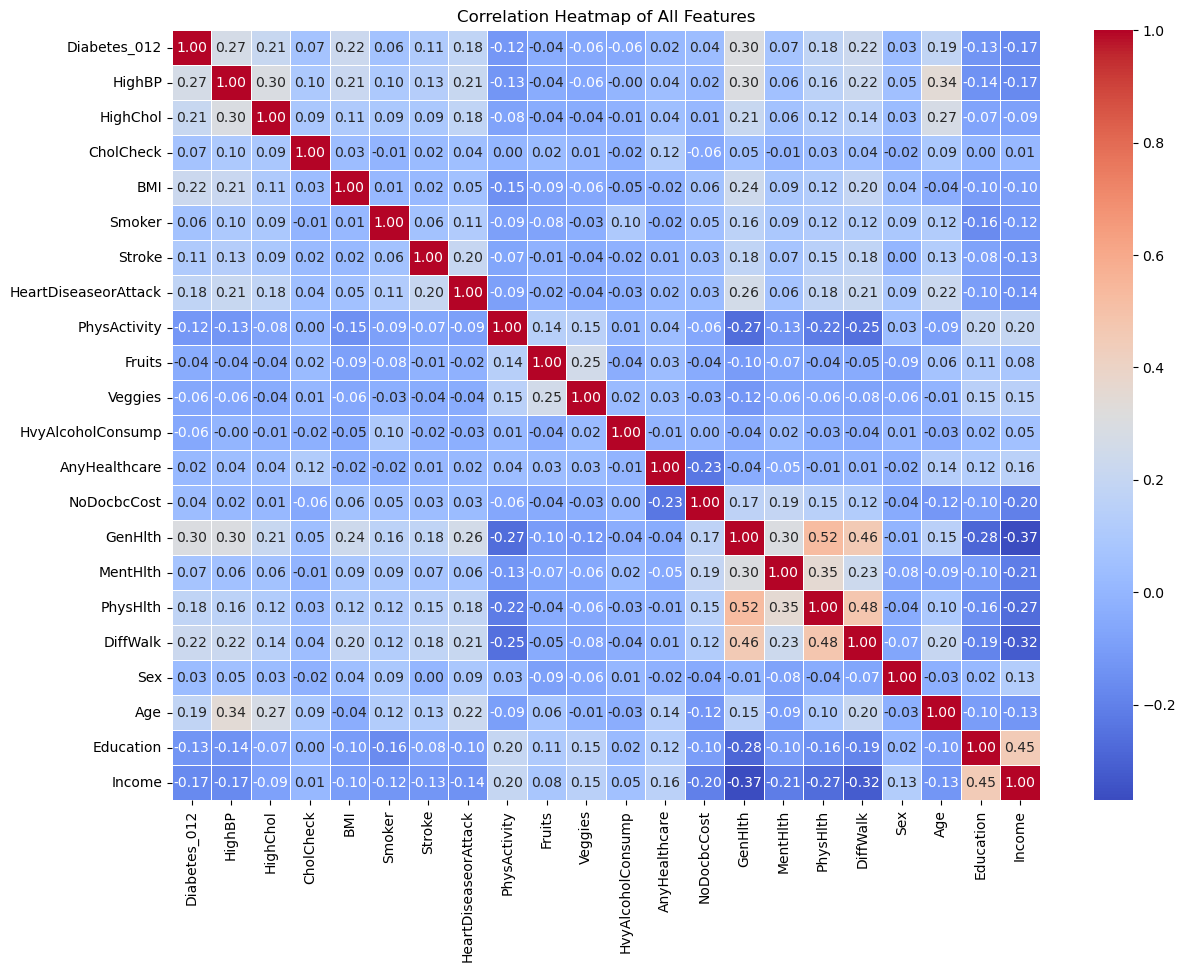

In [85]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

### Correlation Heatmap Analysis

**Strong positive correlations with Diabetes_012 (target):**
- **GenHlth (0.30):** Poor general health is the strongest predictor of diabetes.
- **HighBP (0.27):** High blood pressure is strongly associated with diabetes.
- **BMI (0.22):** Higher BMI is linked to increased diabetes risk.
- **HighChol (0.21):** High cholesterol shows a moderate positive correlation.
- **DiffWalk (0.22):** Difficulty walking is associated with higher diabetes rates.
- **Age (0.19):** Older age groups show higher diabetes prevalence.
- **HeartDiseaseorAttack (0.18):** History of heart disease correlates with diabetes.

**Negative correlations with Diabetes_012 (protective factors):**
- **Income (-0.17):** Higher income is associated with lower diabetes rates.
- **PhysActivity (-0.12):** Physical activity reduces diabetes risk.
- **Education (-0.13):** Higher education is linked to lower diabetes rates.

**Notable correlations between features:**
- **GenHlth and PhysHlth (0.52):** Poor general health strongly relates to more bad physical health days.
- **GenHlth and DiffWalk (0.46):** Poor general health is linked to difficulty walking.
- **Education and Income (0.45):** Higher education is associated with higher income.

## 6. Feature Engineering

We create three new meaningful features to improve model performance:

- **BMI_Category:** Categorizes BMI into Underweight(1), Normal(2), Overweight(3), Obese(4)
- **Health_Score:** Combined score of mental and physical bad health days (MentHlth + PhysHlth)
- **Lifestyle_Risk:** Combined score of smoking, heavy alcohol consumption and physical inactivity

In [190]:
# Feature Engineering

# 1. BMI Category
df['BMI_Category'] = pd.cut(df['BMI'], 
                             bins=[0, 18.5, 24.9, 29.9, 100], 
                             labels=[1, 2, 3, 4])  # 1=Underweight, 2=Normal, 3=Overweight, 4=Obese
df['BMI_Category'] = df['BMI_Category'].astype(int)

# 2. Mental and Physical Health Score
df['Health_Score'] = df['MentHlth'] + df['PhysHlth']

# 3. Lifestyle Risk Score
df['Lifestyle_Risk'] = df['Smoker'] + df['HvyAlcoholConsump'] + (1 - df['PhysActivity'])

print("New features created successfully")
print("Updated dataset shape:", df.shape)
df[['BMI', 'BMI_Category', 'MentHlth', 'PhysHlth', 'Health_Score', 
    'Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'Lifestyle_Risk']].head()

New features created successfully
Updated dataset shape: (253680, 25)


,BMI,BMI_Category,MentHlth,PhysHlth,Health_Score,Smoker,HvyAlcoholConsump,PhysActivity,Lifestyle_Risk
0,40.0,4,18.0,15.0,33.0,1,0,0,2
1,25.0,3,0.0,0.0,0.0,1,0,1,1
2,28.0,3,30.0,30.0,60.0,0,0,0,1
3,27.0,3,0.0,0.0,0.0,0,0,1,0
4,24.0,2,3.0,0.0,3.0,0,0,1,0


### Feature Engineering Summary

Three new features were created and all show positive correlation with diabetes:

1) **BMI_Category (0.21):** Categorizes BMI into Underweight (1), Normal (2), Overweight (3), 
and Obese (4). Shows the strongest correlation among new features, confirming BMI is a 
significant risk factor.

2) **Health_Score (0.16):** Combined score of mental and physical bad health days. 
Higher scores indicate more days of poor health, which is associated with higher diabetes risk.

3) **Lifestyle_Risk (0.10):** Combined score of smoking, heavy alcohol consumption and 
physical inactivity. Higher scores indicate unhealthier lifestyle choices associated 
with increased diabetes risk.

All three features will be kept for model training.

In [193]:
# Correlation of new features with target
new_features = ['BMI_Category', 'Health_Score', 'Lifestyle_Risk']

correlation_new = df[new_features + ['Diabetes_012']].corr()['Diabetes_012'].drop('Diabetes_012')
print("Correlation of New Features with Diabetes_012:\n")
print(correlation_new)

Correlation of New Features with Diabetes_012:

BMI_Category      0.210985
Health_Score      0.156626
Lifestyle_Risk    0.095428
Name: Diabetes_012, dtype: float64


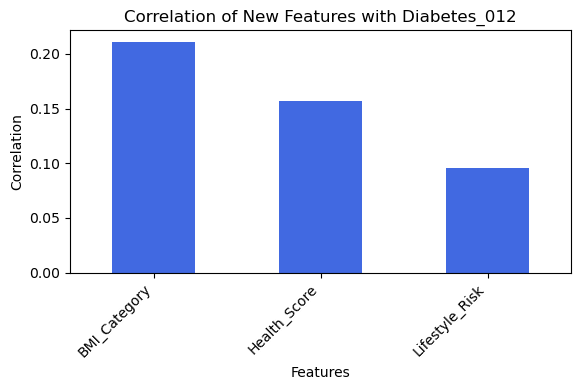

In [195]:
# Correlation of new features with target
new_features = ['BMI_Category', 'Health_Score', 'Lifestyle_Risk']

plt.figure(figsize=(6, 4))
df[new_features + ['Diabetes_012']].corr()['Diabetes_012'].drop('Diabetes_012').plot(kind='bar', color='royalblue')
plt.title('Correlation of New Features with Diabetes_012')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### New Features Correlation Summary

- **BMI_Category (0.21):** Strongest among the three new features, higher BMI category is clearly associated with higher diabetes risk.
- **Health_Score (0.16):** Combined mental and physical health days shows moderate correlation, poor health days are linked to diabetes.
- **Lifestyle_Risk (0.10):** Unhealthy lifestyle choices show a positive correlation with diabetes risk.



## 7. Handling Class Imbalance - SMOTE

Before model training we need to address the severe class imbalance in the dataset.
We first visualize the imbalance and then apply SMOTE (Synthetic Minority Oversampling 
Technique) to balance all three classes in the training data.

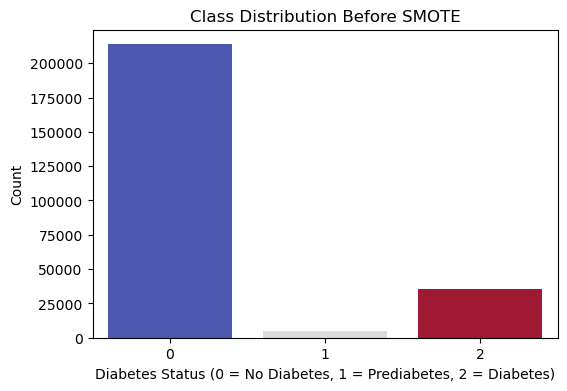

Class Distribution:
 Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64

Class Distribution (%):
 Diabetes_012
0    84.241170
2    13.933302
1     1.825528
Name: proportion, dtype: float64


In [109]:
# Class Imbalance Check
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_012', data=df, hue='Diabetes_012', palette='coolwarm', legend=False)
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Diabetes Status (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)')
plt.ylabel('Count')
plt.show()

class_dist = df['Diabetes_012'].value_counts()
print("Class Distribution:\n", class_dist)
print("\nClass Distribution (%):\n", df['Diabetes_012'].value_counts(normalize=True) * 100)

### Class Imbalance Problem

The dataset shows severe class imbalance:
- No Diabetes (0): 213,703 samples (84.24%) — dominant class
- Diabetes (2): 35,346 samples (13.93%) — moderate representation
- Prediabetes (1): 4,631 samples (1.83%) — severely underrepresented

The Prediabetes class is nearly 46x underrepresented compared to No Diabetes.
Without handling this imbalance the model will be heavily biased towards 
predicting No Diabetes. We will use SMOTE to balance all three classes 
before model training.

## SMOTE

Before SMOTE: Counter({0: 170962, 2: 28277, 1: 3705})
After SMOTE: Counter({0: 170962, 2: 170962, 1: 170962})


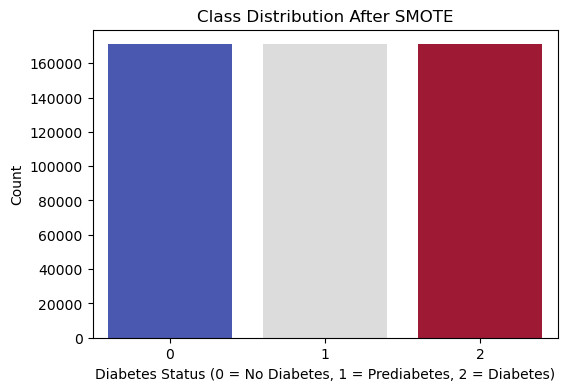

In [113]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Define features and target
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:", Counter(y_train))

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_resampled))

# Visualize after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, hue=y_train_resampled, palette='coolwarm', legend=False)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Diabetes Status (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)')
plt.ylabel('Count')
plt.show()

### SMOTE Results

After applying SMOTE all three classes are perfectly balanced:
- No Diabetes (0): 170,962 samples
- Prediabetes (1): 170,962 samples (was only 3,705 before)
- Diabetes (2): 170,962 samples

Total training samples increased from 202,944 to 512,886.
The model can now learn equally from all three classes without any bias.

## 8. Feature Scaling

We apply StandardScaler to normalize all features to mean=0 and std=1. 
This ensures all features are on the same scale so Logistic Regression 
treats them all fairly regardless of their original range.
- fit_transform is applied on training data only
- transform is applied on test data to avoid data leakage

In [119]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling applied successfully")
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Feature Scaling applied successfully
Training set shape: (512886, 24)
Testing set shape: (50736, 24)


### Data Leakage Check

No data leakage detected:
- No overlap between training and testing indices
- StandardScaler was fit only on training data (mean and std learned from training only)
- SMOTE was applied only on training data
- Test data was only transformed not fit, preserving real world distribution


In [199]:
# Data Leakage Check
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)
print("Training target shape:", y_train_resampled.shape)
print("Testing target shape:", y_test.shape)

# Check if test data is in training data
print("\nAny overlap between train and test indices:", 
      len(set(X_train.index) & set(X_test.index)) > 0)

# Check scaler was fit only on training data
print("\nScaler mean (first 5 features):", scaler.mean_[:5])
print("Scaler std (first 5 features):", scaler.scale_[:5])

Training set shape: (512886, 24)
Testing set shape: (50736, 24)
Training target shape: (512886,)
Testing target shape: (50736,)

Any overlap between train and test indices: False

Scaler mean (first 5 features): [ 0.50407303  0.46704336  0.97477412 30.12490068  0.40402936]
Scaler std (first 5 features): [0.49998341 0.49891268 0.1568105  6.98359622 0.4907032 ]


## 9. Model Training

We train three machine learning models on the balanced and scaled training data:

- **Logistic Regression** (max_iter=1000, class_weight='balanced') — baseline linear model
- **Random Forest** (n_estimators=100, max_depth=10, class_weight='balanced') — ensemble tree-based model  
- **XGBoost** (n_estimators=100, eval_metric='mlogloss') — gradient boosting model

All models are trained on SMOTE balanced data (512,886 samples) and 
evaluated on the original test data (50,736 samples).

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_resampled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_resampled)

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_train_resampled)

print("Logistic Regression Training Accuracy:", accuracy_score(y_train_resampled, lr.predict(X_train_scaled)))
print("Logistic Regression Testing Accuracy:", accuracy_score(y_test, lr.predict(X_test_scaled)))

print("Random Forest Training Accuracy:", accuracy_score(y_train_resampled, rf.predict(X_train_scaled)))
print("Random Forest Testing Accuracy:", accuracy_score(y_test, rf.predict(X_test_scaled)))

print("XGBoost Training Accuracy:", accuracy_score(y_train_resampled, xgb.predict(X_train_scaled)))
print("XGBoost Testing Accuracy:", accuracy_score(y_test, xgb.predict(X_test_scaled)))

Logistic Regression Training Accuracy: 0.5653634530870408
Logistic Regression Testing Accuracy: 0.660970514033428
Random Forest Training Accuracy: 0.992241940704172
Random Forest Testing Accuracy: 0.782797224850205
XGBoost Training Accuracy: 0.7392636960260175
XGBoost Testing Accuracy: 0.7484429202144434


### Model Accuracy Summary

| Model | Training Accuracy | Testing Accuracy |
|-------|------------------|-----------------|
| Logistic Regression | 56.5% | 66.1% |
| Random Forest | 99.2% | 78.3% |
| XGBoost | 73.9% | 74.8% |

**Key Observations:**
- **Logistic Regression** is underfitting — too simple for this dataset
- **Random Forest** is overfitting — 99.2% training vs 78.3% testing is a large gap
- **XGBoost** is the most balanced model — training and testing accuracy are very close with no signs of overfitting


## 10. Classification Report

A detailed breakdown of Precision, Recall and F1-Score for each class.
This gives a better picture than accuracy alone especially for imbalanced datasets.

- **Precision:** Of all predicted positives how many were actually positive
- **Recall:** Of all actual positives how many were correctly predicted
- **F1-Score:** Harmonic mean of precision and recall — best metric for imbalanced classes

In [140]:
from sklearn.metrics import classification_report

# Classification Report
print("Logistic Regression Performance:")
print(classification_report(y_test, lr.predict(X_test_scaled), 
      target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

print("Random Forest Performance:")
print(classification_report(y_test, rf.predict(X_test_scaled), 
      target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

print("XGBoost Performance:")
print(classification_report(y_test, xgb.predict(X_test_scaled), 
      target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

Logistic Regression Performance:
              precision    recall  f1-score   support

 No Diabetes       0.92      0.68      0.78     42741
 Prediabetes       0.02      0.16      0.04       926
    Diabetes       0.34      0.60      0.43      7069

    accuracy                           0.66     50736
   macro avg       0.43      0.48      0.42     50736
weighted avg       0.82      0.66      0.72     50736

Random Forest Performance:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.85      0.87     42741
 Prediabetes       0.01      0.01      0.01       926
    Diabetes       0.35      0.46      0.39      7069

    accuracy                           0.78     50736
   macro avg       0.42      0.44      0.43     50736
weighted avg       0.80      0.78      0.79     50736

XGBoost Performance:
              precision    recall  f1-score   support

 No Diabetes       0.91      0.80      0.85     42741
 Prediabetes       0.02      0.05      0.03     

### Classification Report Analysis

All three models struggle with Prediabetes (class 1):
- Logistic Regression Prediabetes F1: 0.04
- Random Forest Prediabetes F1: 0.01
- XGBoost Prediabetes F1: 0.03

This is still the class imbalance problem. Even after SMOTE the Prediabetes 
class only has 926 samples in test set vs 42,741 No Diabetes samples.

**XGBoost is the best overall model** with 75% accuracy and the most 
balanced performance across all three classes:
- No Diabetes F1: 0.85 (best)
- Diabetes F1: 0.42 (best)
- Most consistent between precision and recall

The Prediabetes class remains extremely difficult to predict due to its 
severe underrepresentation in the original dataset (only 1.83%). This is 
a known challenge in real-world healthcare data where prediabetes is often 
undiagnosed. Future work could explore cost-sensitive learning or collecting 
more prediabetes samples to improve prediction.

## Summary of Work Completed and Next Steps

### What We Have Done So Far:
1. **Data Loading** — Loaded CDC BRFSS 2015 dataset (253,680 records, 22 features)
2. **EDA** — Analyzed class distribution, categorical features, numerical features, boxplots and correlation heatmap
3. **Feature Encoding** — Converted all text values to numeric using binary mapping and ordinal encoding
4. **Feature Engineering** — Created 3 new features: BMI_Category, Health_Score, Lifestyle_Risk
5. **Class Imbalance** — Applied SMOTE to balance all three classes to 170,962 samples each
6. **Feature Scaling** — Applied StandardScaler to normalize all features
7. **Model Training** — Trained Logistic Regression, Random Forest and XGBoost
8. **Model Evaluation** — Compared models using accuracy and classification report
9. **Best Model** — XGBoost with 75% accuracy is the best performing model

### Next Steps:
1. **Confusion Matrix** — Visualize prediction errors for all three models
2. **ROC Curve** — Multiclass ROC curve to compare model performance
3. **Feature Importance** — Identify most important features using Random Forest and XGBoost
4. **SHAP Analysis** — Explain model predictions using SHAP values
5. **Cross Validation** — Validate model stability using K-Fold cross validation
6. **Streamlit App** — Deploy XGBoost model as an interactive web application